# Train and evaluate ocDI task on individual and concatenated datasets - with text preprocessing

In [1]:
import json
import os
from functools import partial

In [2]:
import pandas as pd

from sklearn.svm import LinearSVC

In [3]:
from ocdi.split import load_csv
from ocdi.labels import LABEL_SCHEME_TO_MAPPER
from ocdi.svm import preprocessing, train, evaluation, save
from ocdi.evaluate import get_scores_from_preds, get_baseline_theoretic_scores_uniform

In [4]:
model_prefix = "svm-prep"
models_folder = f"ocDI_models/{model_prefix}"
os.makedirs(models_folder, exist_ok=True)
model_pattern = f"{model_prefix}_{{dataset}}"
scores_folder = "scores"
os.makedirs(scores_folder, exist_ok=True)
scores_path = f"{scores_folder}/{model_prefix}-scores.json"

In [5]:
data_root_folder = "../../ocdi_data"
dataset_folders = {
    "concat": "splitv1",
    "wiki": "splitv1",    
    "congres": "splitv1",
    "soft": "splitv1",
    "ttb": "splitud217",
    "forum": "splitv1"
}
dataset_to_labelscheme = {
    "concat": "fasttext",
    "wiki": "wiki",    
    "congres": "congres_stripped",
    "soft": "congres_stripped",
    "ttb": "ttb",
    "forum": "forum"
}
train_datasets = list(dataset_to_labelscheme)

In [6]:
def get_model_path_from_dataset_name(dataset_name):
    model_name = model_pattern.format(dataset=dataset_name)
    # Get model path
    path_model = os.path.join(
        models_folder, 
        model_name+".pickle"
    )
    return path_model

In [7]:
def load_dataset(dataset_name, split):
    # Get path
    split_date = dataset_folders[dataset_name]
    path = os.path.join(
        data_root_folder, 
        dataset_name, 
        f"{dataset_name}_{split_date}", 
        f"{dataset_name}_{split}.csv")

    # Load CSV
    df = load_csv(path)
    
    # Norm labels
    label_scheme = dataset_to_labelscheme[dataset_name]
    label_mapper = LABEL_SCHEME_TO_MAPPER[label_scheme]
    df["dialect"] = df["dialect"].map(label_mapper)
    
    return df

# Train all models

## Set preprocessing and training hyperparameters

In [8]:
# Define custom preprocessors for words and chars
prep_options = {
    "lowercase": True,
    "strip_accents": "ascii",
    "remove_punctuation": True,
    "norm_dup_chars": True,
    "mask_urls": "remove",
    "mask_emails": "remove",
    "mask_numbers": "remove",
    "stopwords_list": None
}
preprocessor = partial(preprocessing.preprocess, **prep_options)

In [9]:
# Configure preprocessing pipeline
preprocessing_params = {
    "words_pipeline": {
        "vectorizer_type": "tfidf",
        "use_idf": True,
        "preprocessor": preprocessor,
        "ngram_range": (1, 1),
        "binary": False,
        "min_df": 2,
        "max_df": 0.9,
        "norm": "l2",
        "sublinear_tf": True,
        "token_pattern": None
    },
    "chars_pipeline": {
        "vectorizer_type": "tfidf",
        "preprocessor": preprocessor,
        "ngram_range": (2, 5),
        "use_idf": True,
        "min_df": 2,
        "max_df": 0.9,
        "norm": "l2",
        "sublinear_tf": True,
        "token_pattern": None
    }
}

In [10]:
model_hyperparams = {"max_iter": 2000, "class_weight": "balanced"}  # LinearSVC

In [11]:
def train_ngram_model_on_dataset(dataset_name):
    # Look for already trained model
    model_path = get_model_path_from_dataset_name(dataset_name)
    if os.path.exists(model_path):
        clf_pipeline = save.load_sklearn_pipeline(model_path)
        print(f"Loaded existing model from {model_path}")
    
    else:
        # Load training data
        df_train = load_dataset(dataset_name, "train")
    
        # Set the preprocessing pipeline
        preprocess_pipeline, words_transformer, chars_transformer = preprocessing.make_preprocess_pipeline(
            preprocessing_params, tokenizer=preprocessing.tokenize_text
        )
    
        # Train model
        model = LinearSVC(**model_hyperparams)  
        clf_pipeline = train.train_model(preprocess_pipeline, model, df_train, label_col="dialect")
    
        # Save model to file
        save.save_sklearn_pipeline(clf_pipeline, model_path)
        print(f"Model saved to {model_path}")

    return clf_pipeline

In [12]:
def show_top_features(clf_pipeline, n=20):
    # Show main features
    for dia, top_features in evaluation.get_top_features(clf_pipeline, n).items():
        print(f"- {dia}: {' '.join(top_features)}\n")

In [13]:
train_clfs = {}

## Concat-train

In [14]:
dataset_name = "concat"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

/home/onedey/Documents/Code/COLaF/OcWikiDialects/venv_wiki_311/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline fitting done in 0:06:49.632152
Model saved to ocDI_models/svm-prep/svm-prep_concat.pickle
- ara: w_determinants w_adjectius w_aran w_lesan w_referencies w_telediario w_enta w_substantius w_der w_galin w_comandar w_daran w_escampar w_boira w_ues w_eth c_aran w_deth w_plurau c_∅aran

- auv: w_cercar w_delh w_z w_pueis w_ves c_∅cerc w_charrade w_gibert w_h c_rafi∅ w_dreita c_∅cer w_embei w_lacunas w_secle w_arcac w_barges w_gonin w_autrac w_quintin

- gas: w_dens w_dab w_ei w_qu c_au w_mei c_u∅ w_deu w_quei w_enta w_dambe w_ed w_ua w_suu w_shens w_conselher c_an w_casteth w_termi w_veng

- lan: w_del w_sense c_al∅ w_sul w_aude w_lauragues w_savartes c_∅s∅ w_aquelas w_al w_ex w_marty w_de w_dels w_ambe w_general w_drecha w_pel w_res w_totes

- lim: w_quo w_daus w_administracion w_maires w_queu w_ente w_quela w_na w_prononciat w_emb w_io w_quel w_queste w_quilhs w_sei w_pense w_brisa w_gut w_mascher w_sabe

- nic: c_ou w_minga w_ligna w_proprietats c_oun c_∅ma∅ w_gran w_fichie w_ad

In [15]:
show_top_features(clf_pipeline, n=10)

- ara: w_determinants w_adjectius w_aran w_lesan w_referencies w_telediario w_enta w_substantius w_der w_galin

- auv: w_cercar w_delh w_z w_pueis w_ves c_∅cerc w_charrade w_gibert w_h c_rafi∅

- gas: w_dens w_dab w_ei w_qu c_au w_mei c_u∅ w_deu w_quei w_enta

- lan: w_del w_sense c_al∅ w_sul w_aude w_lauragues w_savartes c_∅s∅ w_aquelas w_al

- lim: w_quo w_daus w_administracion w_maires w_queu w_ente w_quela w_na w_prononciat w_emb

- nic: c_ou w_minga w_ligna w_proprietats c_oun c_∅ma∅ w_gran w_fichie w_adressa w_publica

- pro: w_lei w_leis w_dau w_deis w_dei w_premiera w_istoria w_fr w_pou w_direccions

- viv: w_internes w_poetz c_aa w_recercha w_navigaor c_aa∅ w_pechon w_segua w_mas w_predefinia



## Congres-train

In [16]:
dataset_name = "congres"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Pipeline fitting done in 0:00:21.615013
Model saved to ocDI_models/svm-prep/svm-prep_congres.pickle
- ara: w_eth w_mes w_aguest w_deth w_enta w_ar w_informacion w_nau w_comandar w_lengua w_aranes w_libre w_des w_portau w_castelhan w_didactics w_exercicis w_dedicat w_lexicografic w_apers

- auv: w_inscripcions w_h w_dau c_∅h∅ w_detalhat w_directament w_passara w_bal w_organizadas w_festenal w_daici w_seguent w_partatge c_h∅ c_∅h w_biais w_culturala w_programacion w_espectacle w_concert

- gas: w_ed c_u∅ w_dens w_ta w_ua w_deu w_mei w_dab w_que w_qui w_quei w_veder c_au c_au∅ w_suu w_ende w_enta w_ei w_deus c_∅p∅

- lan: w_ex w_del w_es c_l∅ c_al w_amb c_al∅ w_pel w_vos w_als w_aquela w_dins w_revirar w_podon w_se w_al w_baste c_ls c_el∅ w_biarnes

- lim: w_mai w_lestabilitat w_linga w_principis w_cerchar w_comandar w_representativitat w_dordonha w_teledescharjar w_lu w_russe w_cooperacion w_dau w_linformacion w_decisions w_daus w_dcl w_queu w_veire w_diploma

- pro: w_dei w_dau w_signa 

## Soft-train

In [17]:
dataset_name = "soft"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

/home/onedey/Documents/Code/COLaF/OcWikiDialects/venv_wiki_311/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline fitting done in 0:00:38.986825
Model saved to ocDI_models/svm-prep/svm-prep_soft.pickle
- auv: w_be w_gran w_cercha w_ges w_non c_∅be∅ c_ei w_z c_be∅ w_ficheir w_duna w_corchas c_endin w_validacion c_∅endi w_rubrica w_davertiment c_ndin w_daquel w_darreirs

- gas: w_deu w_aqueth w_suber w_mei w_nau w_dens w_autes w_predefinidas w_deus w_descritura w_quei w_shens w_enta w_dab c_isha w_perpausat w_mot w_navigader w_aquera w_quetz

- lan: w_s w_amp c_d∅ w_nou w_sera w_indica w_n w_contactes w_voletz c_g∅ w_del w_ajuda w_mencionat c_s∅ w_diaspora w_carga w_domeni w_dacces w_responsa c_∅s∅

- lim: w_queu w_brisa w_questa w_mai w_quela w_cercha w_autor w_aura w_adreica w_text w_novela w_escorchieras w_daus w_quel w_dspip w_espera w_queste w_validacion w_crear w_dau

- nic: c_ou w_minga w_fichie c_oun w_inscri w_mot w_quita w_utilisa c_oun∅ w_ligna w_statut w_calendari w_lou w_versioun w_doutis w_gran w_balise w_prova w_sias w_errour

- pro: w_gravatar w_dautentificacion w_siegue w_p

## TTB-train

In [18]:
dataset_name = "ttb"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Pipeline fitting done in 0:00:00.962638
Model saved to ocDI_models/svm-prep/svm-prep_ttb.pickle
- gas: c_m∅ w_ei w_ua w_deus c_∅h w_omi w_dens w_drin w_ca w_rei c_uta∅ w_mes c_uta w_ta w_autes w_prener w_que w_on c_sh w_italia

- lan: w_del w_al w_se w_los c_l∅ w_las w_amb w_mas w_lea w_res c_el∅ w_dels w_tant w_es c_et∅ w_vist c_fa w_sos c_al∅ w_aquel

- lim: w_quo w_io w_donc w_segond w_sor w_creses w_roca w_daus w_ai w_moment w_ren w_saber w_carreu w_pus w_odor w_qui w_aguet w_lor w_darnaudguilhem w_auria

- pro: w_lei w_bas w_fin w_sensa w_de w_esposa w_president w_politics w_resta w_taula w_ai w_siau w_un w_question w_leis w_arribet w_sieu w_set c_gui∅ w_a



## Wiki-train

In [19]:
dataset_name = "wiki"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

/home/onedey/Documents/Code/COLaF/OcWikiDialects/venv_wiki_311/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline fitting done in 0:05:05.840621
Model saved to ocDI_models/svm-prep/svm-prep_wiki.pickle
- ara: w_aran w_referencies w_adjectius w_determinants w_aranes w_lesan w_telediario w_galin w_substantius w_twitter c_aran w_oc c_aran∅ w_boira c_∅aran w_escampar w_psc w_web w_eth c_daran

- auv: w_cercar w_delh w_z w_pueis w_dreita w_ves w_sans w_alh c_∅cha w_arcac w_embei w_gibert w_lacunas w_autrac c_∅ch w_gonin w_sobelh w_ambelh w_quintin c_cha

- gas: w_qu w_deu w_dens w_dab w_ua w_dambe w_dreta w_shens w_mei w_conselher w_veng w_casteth w_damb w_avant c_ish w_suu w_ei c_ercar c_sh w_veder

- lan: w_del w_sense c_al∅ w_sul w_ambe c_l∅ w_aude w_drecha w_dels c_el∅ w_general w_savartes w_marty w_las c_al w_vern w_est w_es w_pel w_al

- lim: w_daus w_maires w_administracion w_mascher w_prononciat w_roiera w_evesque w_priech w_plenartige w_dognon w_vers w_emb w_queu w_intercomunalitat w_context w_vinhana w_fuguet w_fermi w_luec w_liams

- nic: w_lu w_proprietats w_nica w_e w_li w_finda w

## Forum-train

In [20]:
dataset_name = "forum"
clf_pipeline = train_ngram_model_on_dataset(dataset_name)
train_clfs[dataset_name+"-train"] = clf_pipeline
show_top_features(clf_pipeline, n=20)

Pipeline fitting done in 0:00:32.656488
Model saved to ocDI_models/svm-prep/svm-prep_forum.pickle
- gas: w_ei w_mes w_dens w_dab w_deu w_mei w_cau w_aqueth w_ua c_∅h w_deus w_diser w_jo w_suu w_merces c_sh w_deja w_quan w_disi w_com

- lan: w_cal c_al∅ w_amb w_del w_res w_al c_iai∅ c_l∅ w_aquel c_el∅ w_quicom w_pel c_ls∅ w_el c_al w_fa w_aquo c_iai w_ieu w_fum

- lim: w_quo w_na w_io w_daus w_dau w_emb w_sei w_quela w_queu w_nonmas w_ente w_mas c_∅cha w_sabe c_∅ch c_cha w_sabia c_∅quo∅ w_lu w_veiqui

- pro: w_mi w_lei w_dei w_siau w_aqueu w_ti w_pron w_vieu w_cu w_eme w_estre w_tardier w_onte w_li c_lei w_novas w_si w_pou w_beu w_totei



# Evaluate all models on each testset

In [21]:
def evaluate_all_models_on_testset(test_name, trained_clfs):
    all_results_testset = {}
    
    # Load test data
    df_test = load_dataset(test_name, "test")

    # Compute theoretical random baseline
    all_results_testset["baseline_random"] = get_baseline_theoretic_scores_uniform(df_test)    

    # Run evaluation for each model    
    for model_name, clf_pipeline in trained_clfs.items():
        print(f"Predict and evaluate with model {model_name}")
        results = evaluation.evaluate_model(
            clf_pipeline,
            df_test,
            return_preds=False,
            show_confusion_matrix=True,
            label_col="dialect"
        )
        all_results_testset[model_name] = results
        
    return all_results_testset
    

In [22]:
def show_results_table(all_results_dict):
    # Load results in a DataFrame
    df_results = pd.DataFrame.from_dict(
        all_results_dict, orient="index"
    ).sort_values("f1_macro", ascending=False)
    return df_results

In [23]:
all_results_alltestsets = {}

## concat - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:29.496071


Classification report:
              precision    recall  f1-score   support

         ara     0.8621    0.1623    0.2732       154
         auv     0.5811    0.3980    0.4724       603
         gas     0.7569    0.8259    0.7899      1557
         lan     0.5849    0.8830    0.7037      2188
         lim     0.7939    0.6927    0.7398      1051
         nic     0.8320    0.2623    0.3988       774
         pro     0.6200    0.6508    0.6350      1409
         viv     0.5494    0.1745    0.2649       510

    accuracy                         0.6573      8246
   macro avg     0.6975    0.5062    0.5347      8246
weighted avg     0.6759    0.6573    0.6321      8246





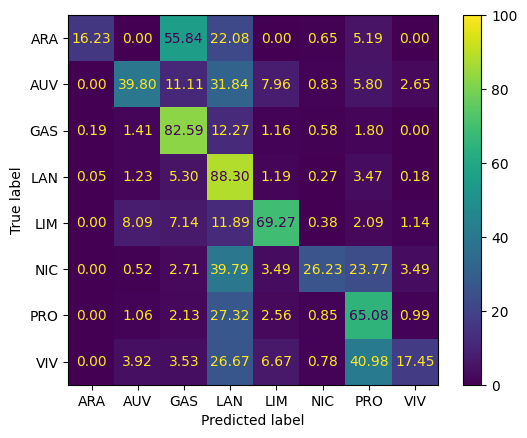

Predict and evaluate with model congres-train
Computed all predictions in 0:00:29.955966


Classification report:
              precision    recall  f1-score   support

         ara     0.9000    0.1169    0.2069       154
         auv     0.2000    0.0017    0.0033       603
         gas     0.5576    0.7900    0.6537      1557
         lan     0.3306    0.8583    0.4773      2188
         lim     0.5833    0.0666    0.1196      1051
         nic        nan    0.0000    0.0000       774
         pro     0.4626    0.0703    0.1220      1409
         viv        nan    0.0000    0.0000       510

    accuracy                         0.3997      8246
   macro avg     0.5057    0.2380    0.1978      8246
weighted avg     0.4475    0.3997    0.2903      8246





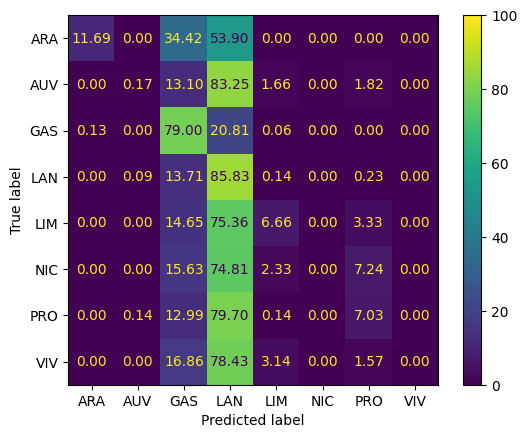

Predict and evaluate with model soft-train
Computed all predictions in 0:00:29.190416


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       154
         auv     0.2208    0.0282    0.0500       603
         gas     0.8675    0.2524    0.3910      1557
         lan     0.3081    0.9666    0.4673      2188
         lim     0.4855    0.0637    0.1127      1051
         nic     0.6753    0.1344    0.2241       774
         pro     0.6250    0.1916    0.2933      1409
         viv     0.1250    0.0314    0.0502       510

    accuracy                         0.3616      8246
   macro avg     0.4725    0.2085    0.1986      8246
weighted avg     0.5111    0.3616    0.2901      8246





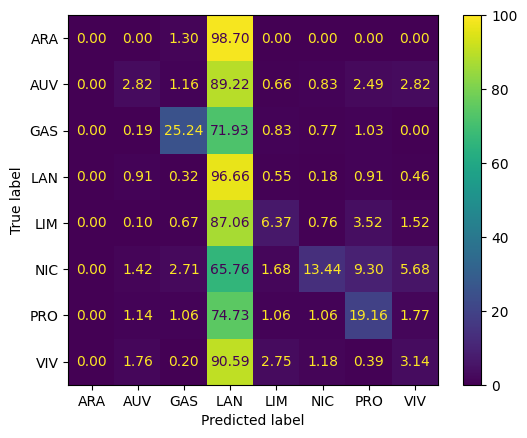

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:29.224806


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       154
         auv        nan    0.0000    0.0000       603
         gas     0.6463    0.6185    0.6321      1557
         lan     0.3569    0.9374    0.5170      2188
         lim     0.6840    0.1503    0.2465      1051
         nic        nan    0.0000    0.0000       774
         pro     0.6264    0.3463    0.4461      1409
         viv        nan    0.0000    0.0000       510

    accuracy                         0.4439      8246
   macro avg     0.5784    0.2566    0.2302      8246
weighted avg     0.5461    0.4439    0.3642      8246





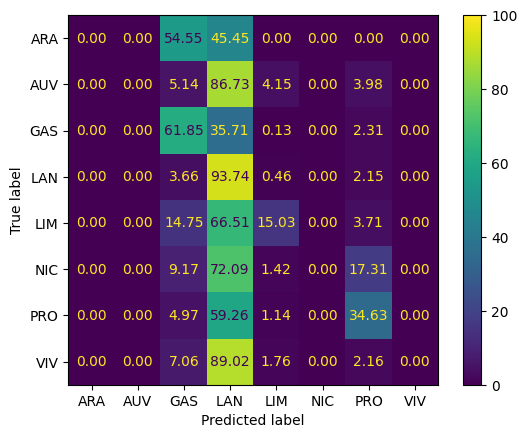

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:29.193473


Classification report:
              precision    recall  f1-score   support

         ara     0.8571    0.3117    0.4571       154
         auv     0.7262    0.3914    0.5086       603
         gas     0.7028    0.7502    0.7257      1557
         lan     0.5946    0.7239    0.6529      2188
         lim     0.8861    0.5404    0.6714      1051
         nic     0.9851    0.2571    0.4078       774
         pro     0.4331    0.8020    0.5625      1409
         viv     0.9885    0.1686    0.2881       510

    accuracy                         0.6087      8246
   macro avg     0.7717    0.4932    0.5343      8246
weighted avg     0.7001    0.6087    0.5938      8246





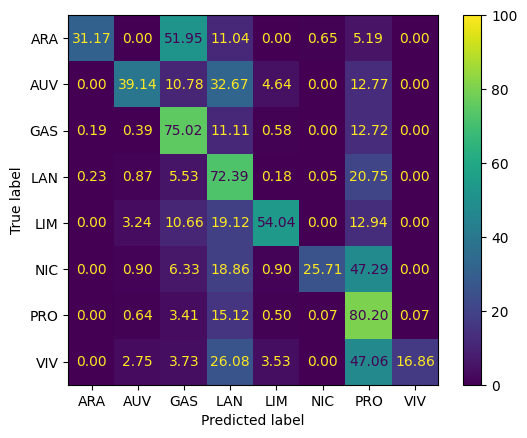

Predict and evaluate with model forum-train
Computed all predictions in 0:00:29.147873


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       154
         auv        nan    0.0000    0.0000       603
         gas     0.5727    0.8067    0.6699      1557
         lan     0.5631    0.6202    0.5903      2188
         lim     0.3350    0.7098    0.4552      1051
         nic        nan    0.0000    0.0000       774
         pro     0.5466    0.5493    0.5480      1409
         viv        nan    0.0000    0.0000       510

    accuracy                         0.5012      8246
   macro avg     0.5043    0.3358    0.2829      8246
weighted avg     0.5231    0.5012    0.4347      8246





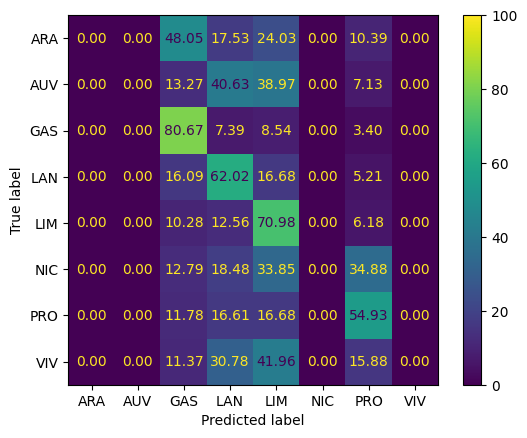

,f1_macro,accuracy,precision_macro,recall_macro,f1_ara,f1_auv,f1_gas,f1_lan,f1_lim,f1_nic,...,precision_viv,recall_ara,recall_auv,recall_gas,recall_lan,recall_lim,recall_nic,recall_pro,recall_viv,speed_avg
concat-train,0.534734,0.657288,0.697535,0.506196,0.273224,0.472441,0.789926,0.703697,0.739837,0.398821,...,0.549383,0.162338,0.398010,0.825947,0.882998,0.692674,0.262274,0.650816,0.174510,3.577016
wiki-train,0.534267,0.608659,0.771693,0.493167,0.457143,0.508621,0.725691,0.652927,0.671395,0.407787,...,0.988506,0.311688,0.391376,0.750161,0.723949,0.540438,0.257106,0.801987,0.168627,3.540319
forum-train,0.282905,0.501213,0.504348,0.335751,0.000000,0.000000,0.669867,0.590257,0.455156,0.000000,...,NaN,0.000000,0.000000,0.806680,0.620201,0.709800,0.000000,0.549326,0.000000,3.534789
ttb-train,0.230209,0.443852,0.578420,0.256570,0.000000,0.000000,0.632097,0.517015,0.246490,0.000000,...,NaN,0.000000,0.000000,0.618497,0.937386,0.150333,0.000000,0.346345,0.000000,3.544119
soft-train,0.198582,0.361630,0.472470,0.208544,0.000000,0.050000,0.391045,0.467300,0.112700,0.224138,...,0.125000,0.000000,0.028192,0.252408,0.966636,0.063749,0.134367,0.191625,0.031373,3.539949
congres-train,0.197849,0.399709,0.505683,0.237963,0.206897,0.003289,0.653734,0.477316,0.119556,0.000000,...,NaN,0.116883,0.001658,0.789981,0.858318,0.066603,0.000000,0.070263,0.000000,3.632788
baseline_random,0.113212,0.125000,0.125000,0.125000,0.032496,0.092272,0.150420,0.169942,0.126216,0.107217,...,0.061848,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,NaN


In [24]:
test_name = "concat"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## congres - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:02.076353


Classification report:
              precision    recall  f1-score   support

         ara     0.9091    0.3125    0.4651        32
         auv     0.6000    0.2500    0.3529        24
         gas     0.8134    0.8720    0.8417       500
         lan     0.7436    0.8760    0.8044       500
         lim     0.8256    0.5259    0.6425       135
       other     0.0000       nan    0.0000         0
         pro     0.6739    0.5210    0.5877       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.7703      1328
   macro avg     0.6522    0.4796    0.4618      1328
weighted avg     0.7738    0.7703    0.7553      1328





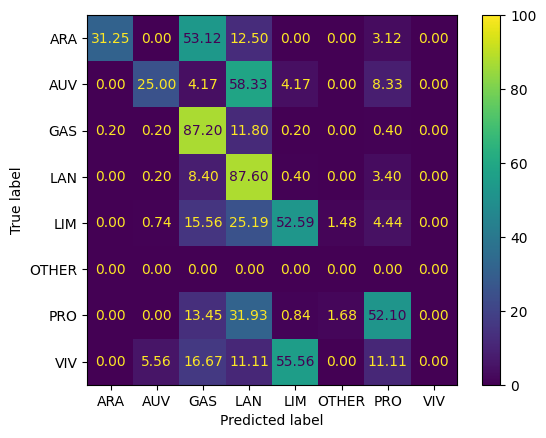

Predict and evaluate with model congres-train
Computed all predictions in 0:00:02.036604


Classification report:
              precision    recall  f1-score   support

         ara     0.8750    0.2188    0.3500        32
         auv        nan    0.0000    0.0000        24
         gas     0.7905    0.8980    0.8408       500
         lan     0.6795    0.9200    0.7816       500
         lim     0.5938    0.1407    0.2275       135
         pro     0.6744    0.2437    0.3580       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.7259      1328
   macro avg     0.7226    0.3459    0.3654      1328
weighted avg     0.7180    0.7259    0.6745      1328





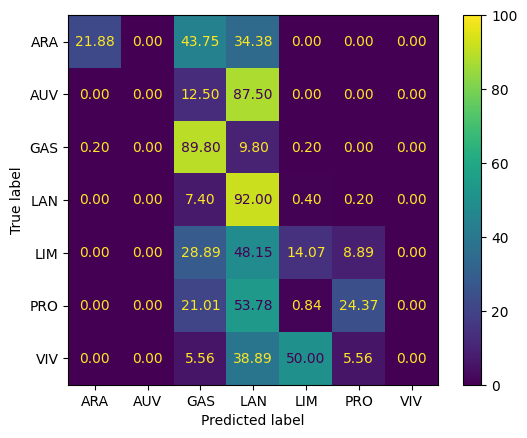

Predict and evaluate with model soft-train
Computed all predictions in 0:00:02.052443


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv        nan    0.0000    0.0000        24
         gas     1.0000    0.2200    0.3607       500
         lan     0.4156    0.9900    0.5855       500
         lim     0.8571    0.0444    0.0845       135
       other     0.0000       nan    0.0000         0
         pro     0.5714    0.0672    0.1203       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.4661      1328
   macro avg     0.5688    0.1888    0.1439      1328
weighted avg     0.7109    0.4661    0.3756      1328





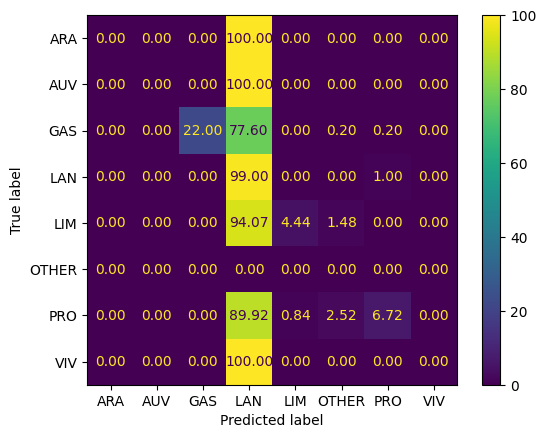

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:02.042934


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv        nan    0.0000    0.0000        24
         gas     0.8067    0.7260    0.7642       500
         lan     0.5795    0.9260    0.7129       500
         lim     0.7917    0.1407    0.2390       135
         pro     0.4727    0.2185    0.2989       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.6559      1328
   macro avg     0.6626    0.2873    0.2878      1328
weighted avg     0.6828    0.6559    0.6072      1328





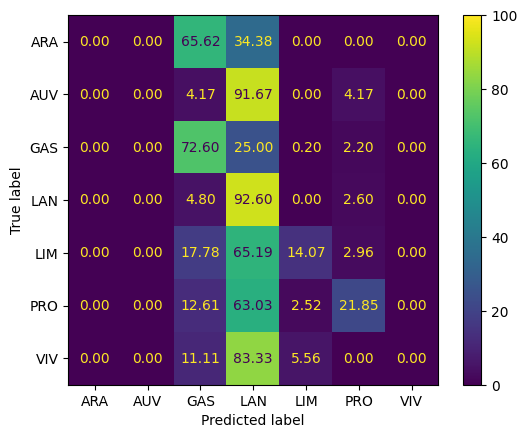

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:02.078265


Classification report:
              precision    recall  f1-score   support

         ara     1.0000    0.4688    0.6383        32
         auv     0.3333    0.2917    0.3111        24
         gas     0.8741    0.7220    0.7908       500
         lan     0.7495    0.7720    0.7606       500
         lim     0.9091    0.3704    0.5263       135
         pro     0.2977    0.7731    0.4299       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.6860      1328
   macro avg     0.6940    0.4854    0.4939      1328
weighted avg     0.7710    0.6860    0.6971      1328





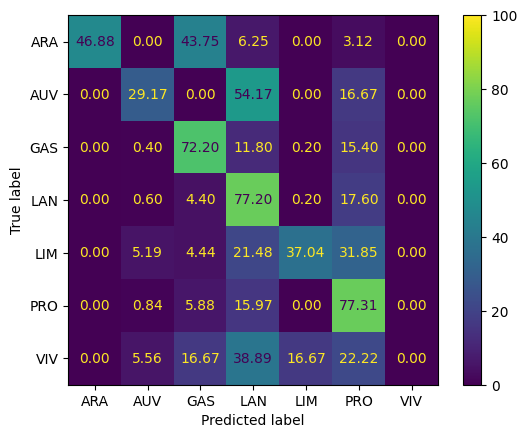

Predict and evaluate with model forum-train
Computed all predictions in 0:00:02.027953


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000        32
         auv        nan    0.0000    0.0000        24
         gas     0.7259    0.8420    0.7796       500
         lan     0.7810    0.5920    0.6735       500
         lim     0.3733    0.8074    0.5105       135
         pro     0.5714    0.3697    0.4490       119
         viv        nan    0.0000    0.0000        18

    accuracy                         0.6551      1328
   macro avg     0.6129    0.3730    0.3447      1328
weighted avg     0.6952    0.6551    0.6392      1328





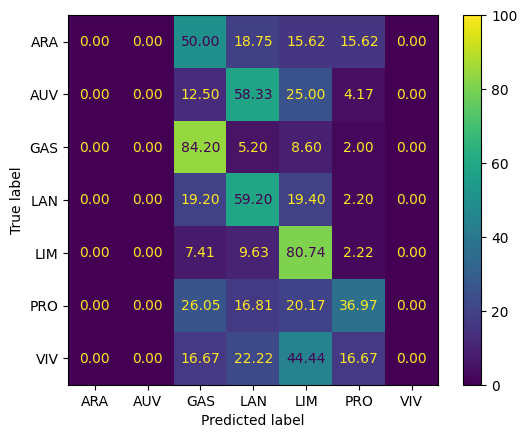

,f1_macro,accuracy,precision_macro,recall_macro,f1_ara,f1_auv,f1_gas,f1_lan,f1_lim,f1_pro,...,recall_auv,recall_gas,recall_lan,recall_lim,recall_pro,recall_viv,f1_other,precision_other,recall_other,speed_avg
wiki-train,0.493860,0.685994,0.693961,0.485414,0.638298,0.311111,0.790800,0.760591,0.526316,0.429907,...,0.291667,0.722000,0.772000,0.370370,0.773109,0.000000,NaN,NaN,NaN,1.564959
concat-train,0.461797,0.770331,0.652236,0.479633,0.465116,0.352941,0.841699,0.804408,0.642534,0.587678,...,0.250000,0.872000,0.876000,0.525926,0.521008,0.000000,0.0,0.0,NaN,1.563519
congres-train,0.365435,0.725904,0.722626,0.345884,0.350000,0.000000,0.840824,0.781648,0.227545,0.358025,...,0.000000,0.898000,0.920000,0.140741,0.243697,0.000000,NaN,NaN,NaN,1.533587
forum-train,0.344663,0.655120,0.612895,0.373022,0.000000,0.000000,0.779630,0.673493,0.510539,0.448980,...,0.000000,0.842000,0.592000,0.807407,0.369748,0.000000,NaN,NaN,NaN,1.527073
ttb-train,0.287844,0.655873,0.662634,0.287318,0.000000,0.000000,0.764211,0.712856,0.238994,0.298851,...,0.000000,0.726000,0.926000,0.140741,0.218487,0.000000,NaN,NaN,NaN,1.538354
soft-train,0.143864,0.466114,0.568838,0.188810,0.000000,0.000000,0.360656,0.585452,0.084507,0.120301,...,0.000000,0.220000,0.990000,0.044444,0.067227,0.000000,0.0,0.0,NaN,1.545514
baseline_random,0.105893,0.142857,0.142857,0.142857,0.041237,0.032086,0.207125,0.207125,0.118786,0.110134,...,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,NaN,NaN,NaN,NaN


In [25]:
test_name = "congres"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## soft - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:01.218028


Classification report:
              precision    recall  f1-score   support

         auv     0.3750    0.2308    0.2857        78
         gas     0.8093    0.7696    0.7889       204
         lan     0.3978    0.9460    0.5601       500
         lim     0.4911    0.4508    0.4701       122
         nic     0.7556    0.2040    0.3213       500
         pro     0.7653    0.3260    0.4572       500
         viv     0.2088    0.2436    0.2249        78

    accuracy                         0.4980      1982
   macro avg     0.5433    0.4530    0.4440      1982
weighted avg     0.6205    0.4980    0.4679      1982





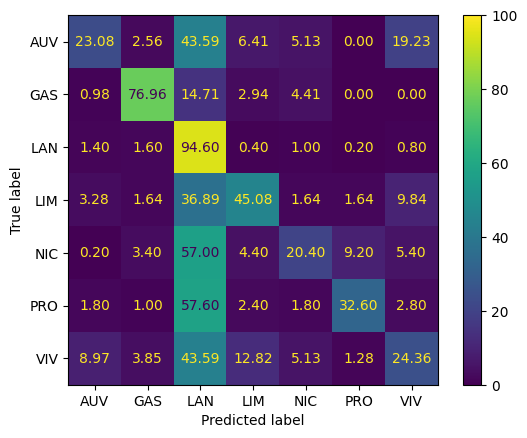

Predict and evaluate with model congres-train
Computed all predictions in 0:00:01.211991


Classification report:
              precision    recall  f1-score   support

         auv     0.0000    0.0000    0.0000        78
         gas     0.3164    0.7941    0.4525       204
         lan     0.2845    0.7720    0.4157       500
         lim     0.2692    0.0574    0.0946       122
         nic        nan    0.0000    0.0000       500
         pro     0.3690    0.0620    0.1062       500
         viv        nan    0.0000    0.0000        78

    accuracy                         0.2957      1982
   macro avg     0.2478    0.2408    0.1527      1982
weighted avg     0.3021    0.2957    0.1841      1982





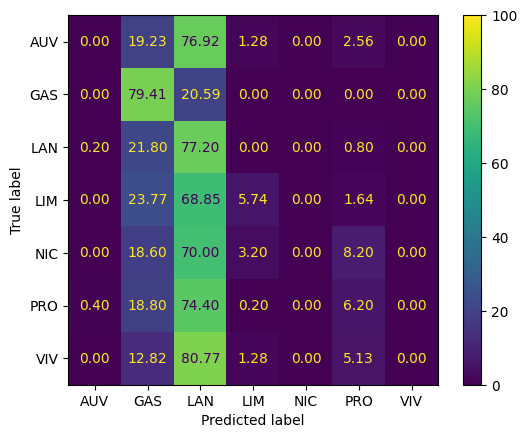

Predict and evaluate with model soft-train
Computed all predictions in 0:00:01.232768


Classification report:
              precision    recall  f1-score   support

         auv     0.2192    0.2051    0.2119        78
         gas     0.6543    0.5196    0.5792       204
         lan     0.3686    0.8840    0.5203       500
         lim     0.4018    0.3689    0.3846       122
         nic     0.7319    0.2020    0.3166       500
         pro     0.7135    0.2640    0.3854       500
         viv     0.1416    0.2051    0.1675        78

    accuracy                         0.4329      1982
   macro avg     0.4616    0.3784    0.3665      1982
weighted avg     0.5639    0.4329    0.4066      1982





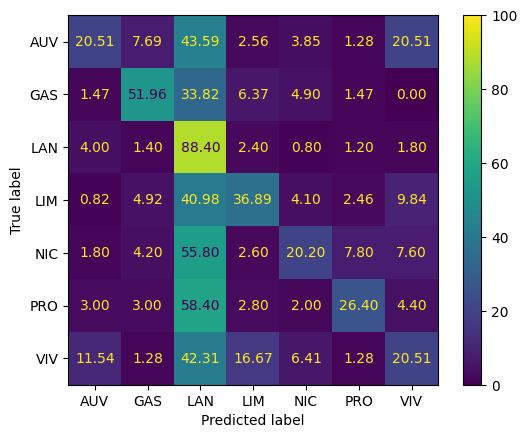

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:01.213602


Classification report:
              precision    recall  f1-score   support

         auv        nan    0.0000    0.0000        78
         gas     0.3921    0.4363    0.4130       204
         lan     0.2923    0.9080    0.4423       500
         lim     0.2778    0.0820    0.1266       122
         nic        nan    0.0000    0.0000       500
         pro     0.5542    0.1840    0.2763       500
         viv        nan    0.0000    0.0000        78

    accuracy                         0.3254      1982
   macro avg     0.3791    0.2300    0.1797      1982
weighted avg     0.4051    0.3254    0.2316      1982





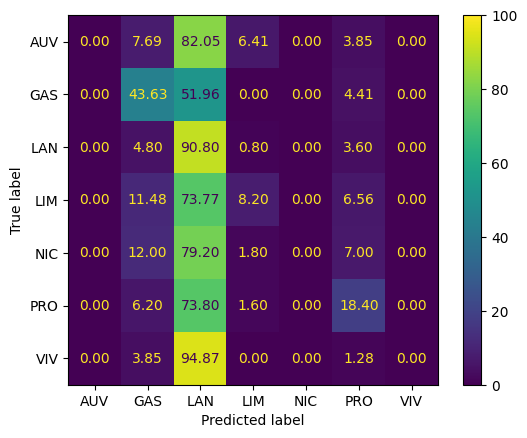

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:01.221585


Classification report:
              precision    recall  f1-score   support

         auv     0.4348    0.2564    0.3226        78
         gas     0.5524    0.6716    0.6062       204
         lan     0.4260    0.5760    0.4898       500
         lim     0.6667    0.3279    0.4396       122
         nic     1.0000    0.1040    0.1884       500
       other     0.0000       nan    0.0000         0
         pro     0.3709    0.6640    0.4760       500
         viv     0.6667    0.0256    0.0494        78

    accuracy                         0.4395      1982
   macro avg     0.5147    0.3751    0.3215      1982
weighted avg     0.5946    0.4395    0.3953      1982





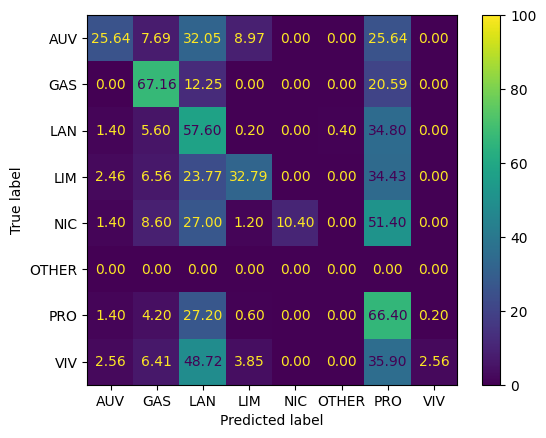

Predict and evaluate with model forum-train
Computed all predictions in 0:00:01.216290


Classification report:
              precision    recall  f1-score   support

         auv        nan    0.0000    0.0000        78
         gas     0.3340    0.7941    0.4702       204
         lan     0.4038    0.5120    0.4515       500
         lim     0.1349    0.6311    0.2222       122
         nic        nan    0.0000    0.0000       500
         pro     0.4212    0.2460    0.3106       500
         viv        nan    0.0000    0.0000        78

    accuracy                         0.3118      1982
   macro avg     0.3235    0.3119    0.2078      1982
weighted avg     0.3749    0.3118    0.2543      1982





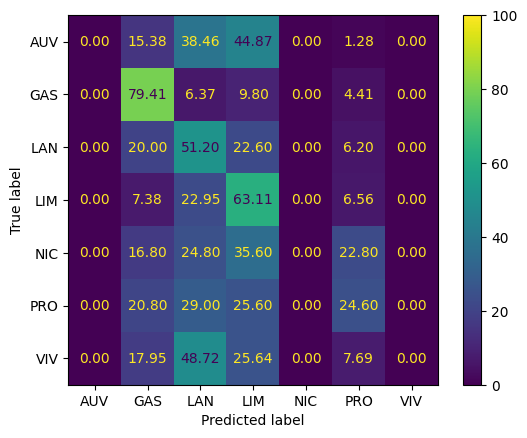

,f1_macro,accuracy,precision_macro,recall_macro,f1_auv,f1_gas,f1_lan,f1_lim,f1_nic,f1_pro,...,recall_gas,recall_lan,recall_lim,recall_nic,recall_pro,recall_viv,speed_avg,f1_other,precision_other,recall_other
concat-train,0.444025,0.497982,0.543253,0.452969,0.285714,0.788945,0.560095,0.470085,0.321260,0.457223,...,0.769608,0.946000,0.450820,0.204000,0.326000,0.243590,0.614545,NaN,NaN,NaN
soft-train,0.366519,0.432896,0.461559,0.378388,0.211921,0.579235,0.520306,0.384615,0.316614,0.385401,...,0.519608,0.884000,0.368852,0.202000,0.264000,0.205128,0.621982,NaN,NaN,NaN
wiki-train,0.321488,0.439455,0.514690,0.375070,0.322581,0.606195,0.489796,0.439560,0.188406,0.475986,...,0.671569,0.576000,0.327869,0.104000,0.664000,0.025641,0.616340,0.0,0.0,NaN
forum-train,0.207796,0.311806,0.323473,0.311895,0.000000,0.470247,0.451499,0.222222,0.000000,0.310606,...,0.794118,0.512000,0.631148,0.000000,0.246000,0.000000,0.613668,NaN,NaN,NaN
ttb-train,0.179733,0.325429,0.379101,0.230035,0.000000,0.412993,0.442280,0.126582,0.000000,0.276276,...,0.436275,0.908000,0.081967,0.000000,0.184000,0.000000,0.612312,NaN,NaN,NaN
congres-train,0.152714,0.295661,0.247827,0.240785,0.000000,0.452514,0.415724,0.094595,0.000000,0.106164,...,0.794118,0.772000,0.057377,0.000000,0.062000,0.000000,0.611499,NaN,NaN,NaN
baseline_random,0.125193,0.142857,0.142857,0.142857,0.061709,0.119648,0.182415,0.086037,0.182415,0.182415,...,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,NaN,NaN,NaN,NaN


In [26]:
test_name = "soft"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## ttb - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:00.682012


Classification report:
              precision    recall  f1-score   support

         gas     0.6667    0.7767    0.7175       103
         lan     0.8960    0.8673    0.8814       437
         lim     0.7429    0.6341    0.6842        41
       other     0.0000       nan    0.0000         0
         pro     0.5758    0.5938    0.5846        32

    accuracy                         0.8222       613
   macro avg     0.5763    0.7180    0.5735       613
weighted avg     0.8305    0.8222    0.8252       613





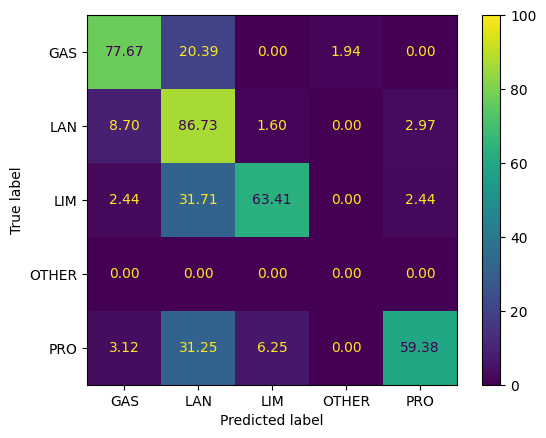

Predict and evaluate with model congres-train
Computed all predictions in 0:00:00.681094


Classification report:
              precision    recall  f1-score   support

         gas     0.4238    0.8641    0.5687       103
         lan     0.8409    0.7620    0.7995       437
         lim     0.5000    0.0244    0.0465        41
       other     0.0000       nan    0.0000         0
         pro     0.7500    0.0938    0.1667        32

    accuracy                         0.6949       613
   macro avg     0.5029    0.4361    0.3163       613
weighted avg     0.7433    0.6949    0.6773       613





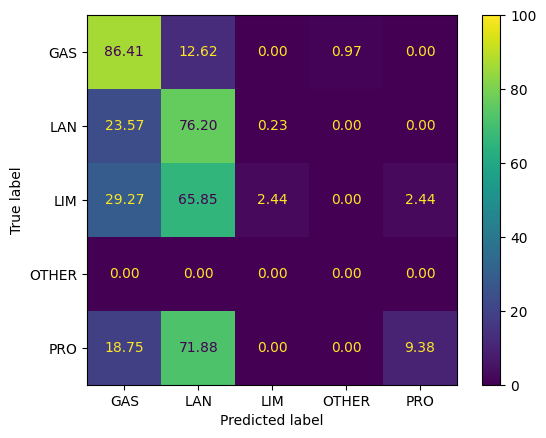

Predict and evaluate with model soft-train
Computed all predictions in 0:00:00.673871


Classification report:
              precision    recall  f1-score   support

         gas     1.0000    0.1456    0.2542       103
         lan     0.7419    0.9931    0.8493       437
         lim     1.0000    0.0244    0.0476        41
       other     0.0000       nan    0.0000         0
         pro     0.5556    0.1562    0.2439        32

    accuracy                         0.7423       613
   macro avg     0.6595    0.3299    0.2790       613
weighted avg     0.7928    0.7423    0.6641       613





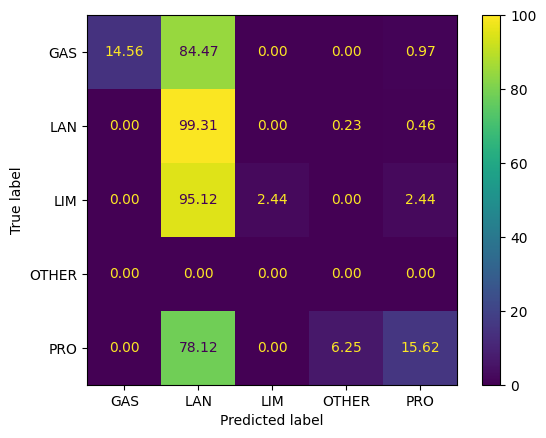

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:00.663502


Classification report:
              precision    recall  f1-score   support

         gas     0.8352    0.7379    0.7835       103
         lan     0.8533    0.9451    0.8969       437
         lim     0.8421    0.3902    0.5333        41
         pro     0.4737    0.2812    0.3529        32

    accuracy                         0.8385       613
   macro avg     0.7511    0.5886    0.6417       613
weighted avg     0.8297    0.8385    0.8251       613





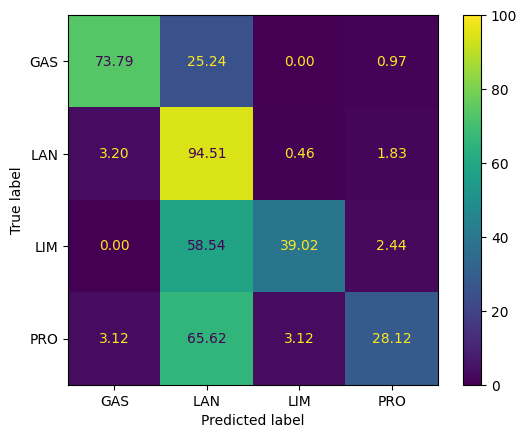

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:00.666189


Classification report:
              precision    recall  f1-score   support

         gas     0.7129    0.6990    0.7059       103
         lan     0.9130    0.6728    0.7747       437
         lim     0.9286    0.3171    0.4727        41
       other     0.0000       nan    0.0000         0
         pro     0.1497    0.7812    0.2513        32

    accuracy                         0.6591       613
   macro avg     0.5408    0.6175    0.4409       613
weighted avg     0.8406    0.6591    0.7156       613





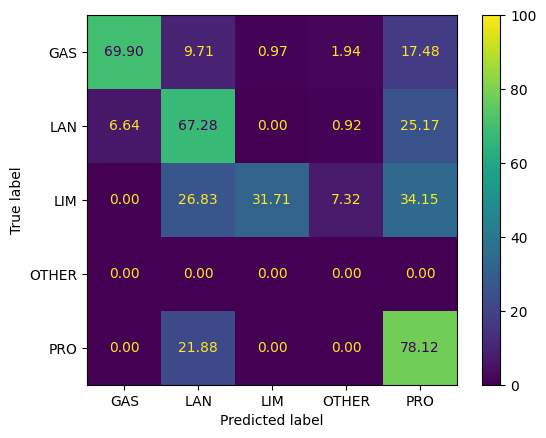

Predict and evaluate with model forum-train
Computed all predictions in 0:00:00.679346


Classification report:
              precision    recall  f1-score   support

         gas     0.5649    0.8447    0.6770       103
         lan     0.9423    0.5606    0.7030       437
         lim     0.2537    0.8293    0.3886        41
         pro     0.2769    0.5625    0.3711        32

    accuracy                         0.6264       613
   macro avg     0.5095    0.6993    0.5349       613
weighted avg     0.7981    0.6264    0.6603       613





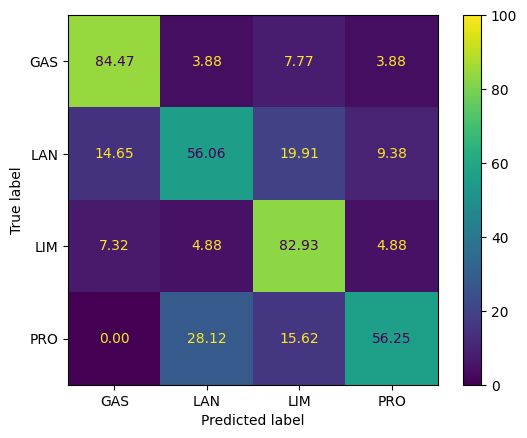

,f1_macro,accuracy,precision_macro,recall_macro,f1_gas,f1_lan,f1_lim,f1_pro,precision_gas,precision_lan,precision_lim,precision_pro,recall_gas,recall_lan,recall_lim,recall_pro,f1_other,precision_other,recall_other,speed_avg
ttb-train,0.641658,0.838499,0.751065,0.588610,0.783505,0.896851,0.533333,0.352941,0.835165,0.853306,0.842105,0.473684,0.737864,0.945080,0.390244,0.28125,NaN,NaN,NaN,1.082385
concat-train,0.573542,0.822186,0.576252,0.717968,0.717489,0.881395,0.684211,0.584615,0.666667,0.895981,0.742857,0.575758,0.776699,0.867277,0.634146,0.59375,0.0,0.0,NaN,1.112581
forum-train,0.534940,0.626427,0.509474,0.699267,0.677043,0.703013,0.388571,0.371134,0.564935,0.942308,0.253731,0.276923,0.844660,0.560641,0.829268,0.56250,NaN,NaN,NaN,1.108232
wiki-train,0.440914,0.659054,0.540837,0.617530,0.705882,0.774704,0.472727,0.251256,0.712871,0.913043,0.928571,0.149701,0.699029,0.672769,0.317073,0.78125,0.0,0.0,NaN,1.086768
congres-train,0.316278,0.694943,0.502944,0.436058,0.568690,0.799520,0.046512,0.166667,0.423810,0.840909,0.500000,0.750000,0.864078,0.762014,0.024390,0.09375,0.0,0.0,NaN,1.111083
soft-train,0.279015,0.742251,0.659487,0.329852,0.254237,0.849315,0.047619,0.243902,1.000000,0.741880,1.000000,0.555556,0.145631,0.993135,0.024390,0.15625,0.0,0.0,NaN,1.099300
baseline_random,0.190765,0.250000,0.250000,0.250000,0.200976,0.370182,0.105534,0.086370,0.168026,0.712887,0.066884,0.052202,0.250000,0.250000,0.250000,0.25000,NaN,NaN,NaN,NaN


In [27]:
test_name = "ttb"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## wiki - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:20.912231


Classification report:
              precision    recall  f1-score   support

         ara     1.0000    0.1230    0.2190       122
         auv     0.6085    0.4311    0.5047       501
         gas     0.6438    0.7880    0.7086       500
         lan     0.5155    0.8323    0.6366       501
         lim     0.8357    0.6879    0.7546       503
         nic     0.9712    0.3686    0.5344       274
         pro     0.5133    0.9528    0.6671       508
         viv     0.9859    0.1691    0.2887       414

    accuracy                         0.6148      3323
   macro avg     0.7592    0.5441    0.5392      3323
weighted avg     0.7109    0.6148    0.5830      3323





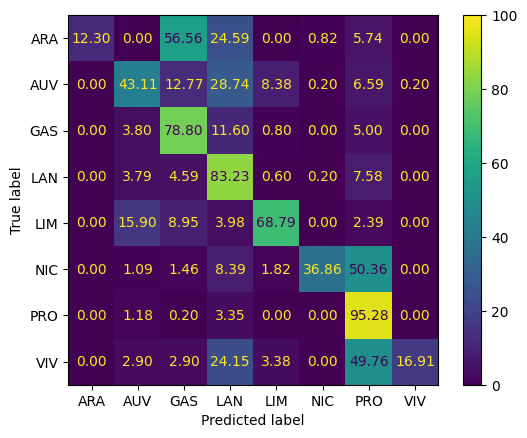

Predict and evaluate with model congres-train
Computed all predictions in 0:00:20.872110


Classification report:
              precision    recall  f1-score   support

         ara     1.0000    0.0902    0.1654       122
         auv     0.5000    0.0020    0.0040       501
         gas     0.5131    0.6640    0.5789       500
         lan     0.1832    0.9301    0.3061       501
         lim     0.6304    0.0577    0.1056       503
         nic        nan    0.0000    0.0000       274
         pro     0.3699    0.0531    0.0929       508
         viv        nan    0.0000    0.0000       414

    accuracy                         0.2606      3323
   macro avg     0.5328    0.2246    0.1566      3323
weighted avg     0.4652    0.2606    0.1701      3323





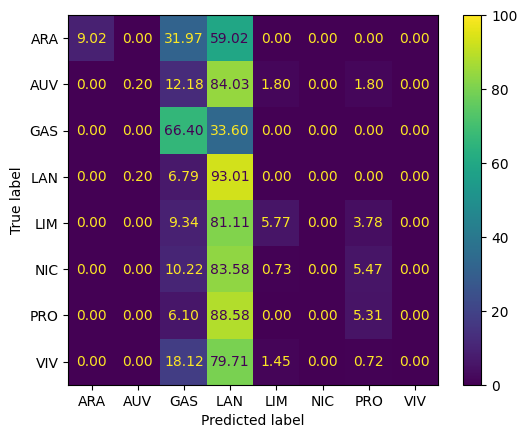

Predict and evaluate with model soft-train
Computed all predictions in 0:00:20.851303


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       122
         auv     0.3333    0.0020    0.0040       501
         gas     0.9735    0.2200    0.3589       500
         lan     0.1650    0.9960    0.2831       501
         lim     0.0000    0.0000    0.0000       503
         nic     0.4286    0.0109    0.0214       274
         pro     0.5915    0.1909    0.2887       508
         viv     0.0000    0.0000    0.0000       414

    accuracy                         0.2137      3323
   macro avg     0.3560    0.1775    0.1195      3323
weighted avg     0.3606    0.2137    0.1432      3323





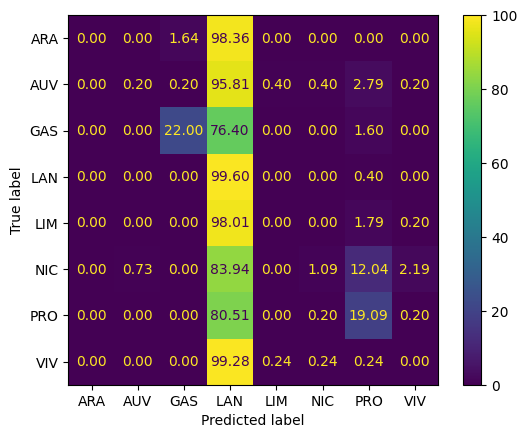

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:20.828483


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       122
         auv        nan    0.0000    0.0000       501
         gas     0.5028    0.5340    0.5179       500
         lan     0.2125    0.9521    0.3474       501
         lim     0.5733    0.0855    0.1488       503
         nic        nan    0.0000    0.0000       274
         pro     0.6377    0.5925    0.6143       508
         viv        nan    0.0000    0.0000       414

    accuracy                         0.3274      3323
   macro avg     0.4816    0.2705    0.2036      3323
weighted avg     0.4822    0.3274    0.2467      3323





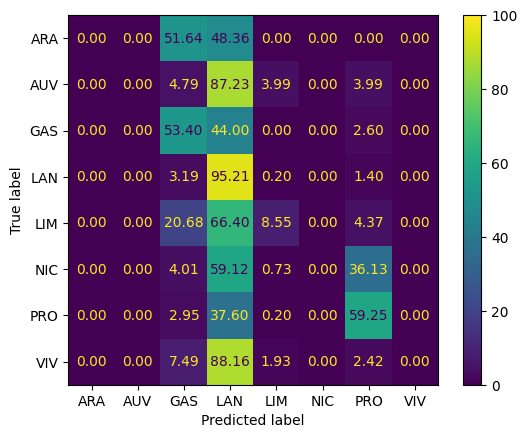

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:21.056598


Classification report:
              precision    recall  f1-score   support

         ara     0.9706    0.2705    0.4231       122
         auv     0.8745    0.4172    0.5649       501
         gas     0.6028    0.7800    0.6800       500
         lan     0.5050    0.8084    0.6216       501
         lim     0.8951    0.6958    0.7830       503
         nic     0.9866    0.5365    0.6950       274
         pro     0.5005    0.9626    0.6586       508
         viv     1.0000    0.2029    0.3373       414

    accuracy                         0.6341      3323
   macro avg     0.7919    0.5842    0.5954      3323
weighted avg     0.7523    0.6341    0.6153      3323





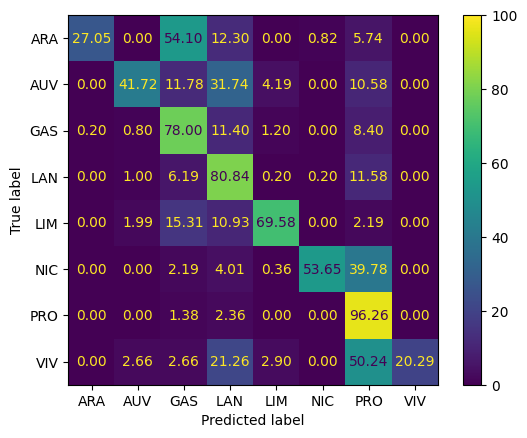

Predict and evaluate with model forum-train
Computed all predictions in 0:00:20.947996


Classification report:
              precision    recall  f1-score   support

         ara        nan    0.0000    0.0000       122
         auv        nan    0.0000    0.0000       501
         gas     0.4986    0.7220    0.5899       500
         lan     0.3863    0.6747    0.4913       501
         lim     0.3135    0.5865    0.4086       503
         nic        nan    0.0000    0.0000       274
         pro     0.5032    0.7756    0.6104       508
         viv        nan    0.0000    0.0000       414

    accuracy                         0.4177      3323
   macro avg     0.4254    0.3448    0.2625      3323
weighted avg     0.4255    0.4177    0.3180      3323





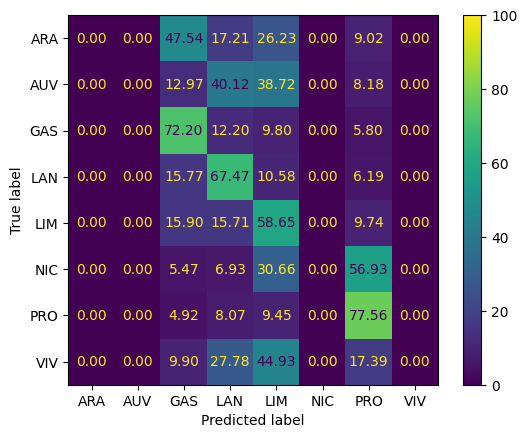

,f1_macro,accuracy,precision_macro,recall_macro,f1_ara,f1_auv,f1_gas,f1_lan,f1_lim,f1_nic,...,precision_viv,recall_ara,recall_auv,recall_gas,recall_lan,recall_lim,recall_nic,recall_pro,recall_viv,speed_avg
wiki-train,0.595448,0.634066,0.791883,0.584232,0.423077,0.564865,0.680035,0.621642,0.782998,0.695035,...,1.000000,0.270492,0.417166,0.780,0.808383,0.695825,0.536496,0.962598,0.202899,6.336623
concat-train,0.539217,0.614806,0.759221,0.544093,0.218978,0.504673,0.708633,0.636641,0.754635,0.534392,...,0.985915,0.122951,0.431138,0.788,0.832335,0.687873,0.368613,0.952756,0.169082,6.293178
forum-train,0.262514,0.417695,0.425398,0.344840,0.000000,0.000000,0.589869,0.491279,0.408587,0.000000,...,NaN,0.000000,0.000000,0.722,0.674651,0.586481,0.000000,0.775591,0.000000,6.303941
ttb-train,0.203554,0.327415,0.481586,0.270513,0.000000,0.000000,0.517944,0.347414,0.148789,0.000000,...,NaN,0.000000,0.000000,0.534,0.952096,0.085487,0.000000,0.592520,0.000000,6.267976
congres-train,0.156620,0.260608,0.532769,0.224638,0.165414,0.003976,0.578901,0.306076,0.105647,0.000000,...,NaN,0.090164,0.001996,0.664,0.930140,0.057654,0.000000,0.053150,0.000000,6.281104
baseline_random,0.120662,0.125000,0.125000,0.125000,0.056757,0.136680,0.136556,0.136680,0.136927,0.099365,...,0.124586,0.125000,0.125000,0.125,0.125000,0.125000,0.125000,0.125000,0.125000,NaN
soft-train,0.119503,0.213662,0.355976,0.177487,0.000000,0.003968,0.358891,0.283121,0.000000,0.021352,...,0.000000,0.000000,0.001996,0.220,0.996008,0.000000,0.010949,0.190945,0.000000,6.274843


In [28]:
test_name = "wiki"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

## forum - test

Predict and evaluate with model concat-train
Computed all predictions in 0:00:04.516429


Classification report:
              precision    recall  f1-score   support

         gas     0.9241    0.8760    0.8994       250
         lan     0.7679    0.9000    0.8287       250
         lim     0.8519    0.9200    0.8846       250
       other     0.0000       nan    0.0000         0
         pro     0.9545    0.7560    0.8438       250

    accuracy                         0.8630      1000
   macro avg     0.6997    0.8630    0.6913      1000
weighted avg     0.8746    0.8630    0.8641      1000





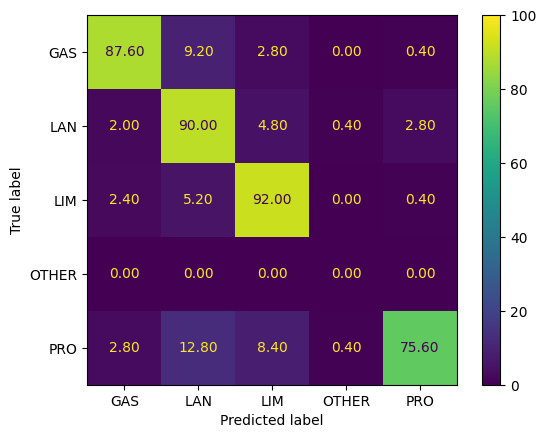

Predict and evaluate with model congres-train
Computed all predictions in 0:00:04.521953


Classification report:
              precision    recall  f1-score   support

         gas     0.7361    0.7920    0.7630       250
         lan     0.3296    0.9320    0.4869       250
         lim     1.0000    0.0560    0.1061       250
         pro     0.9000    0.0360    0.0692       250

    accuracy                         0.4540      1000
   macro avg     0.7414    0.4540    0.3563      1000
weighted avg     0.7414    0.4540    0.3563      1000





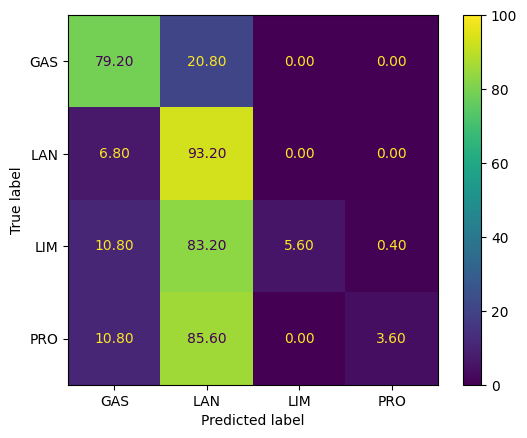

Predict and evaluate with model soft-train
Computed all predictions in 0:00:04.550028


Classification report:
              precision    recall  f1-score   support

         gas     0.9811    0.2080    0.3432       250
         lan     0.2832    0.9800    0.4395       250
         lim     1.0000    0.0600    0.1132       250
       other     0.0000       nan    0.0000         0
         pro     0.4667    0.1120    0.1806       250

    accuracy                         0.3400      1000
   macro avg     0.5462    0.3400    0.2153      1000
weighted avg     0.6828    0.3400    0.2691      1000





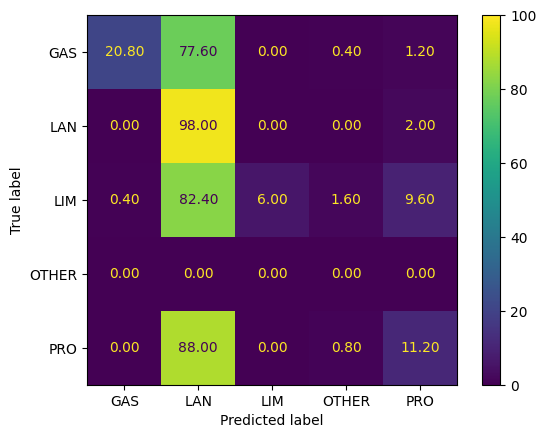

Predict and evaluate with model ttb-train
Computed all predictions in 0:00:04.524999


Classification report:
              precision    recall  f1-score   support

         gas     0.8796    0.6720    0.7619       250
         lan     0.3669    0.9760    0.5333       250
         lim     0.9091    0.2800    0.4281       250
         pro     0.8955    0.2400    0.3785       250

    accuracy                         0.5420      1000
   macro avg     0.7628    0.5420    0.5255      1000
weighted avg     0.7628    0.5420    0.5255      1000





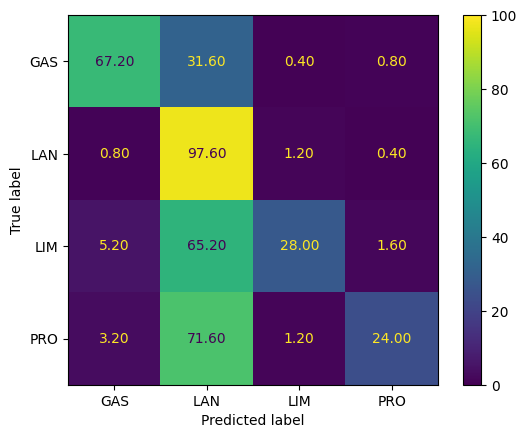

Predict and evaluate with model wiki-train
Computed all predictions in 0:00:04.605122


Classification report:
              precision    recall  f1-score   support

         gas     0.8221    0.8320    0.8270       250
         lan     0.6046    0.8440    0.7045       250
         lim     0.9504    0.4600    0.6199       250
       other     0.0000       nan    0.0000         0
         pro     0.7356    0.7680    0.7515       250

    accuracy                         0.7260      1000
   macro avg     0.6226    0.7260    0.5806      1000
weighted avg     0.7782    0.7260    0.7257      1000





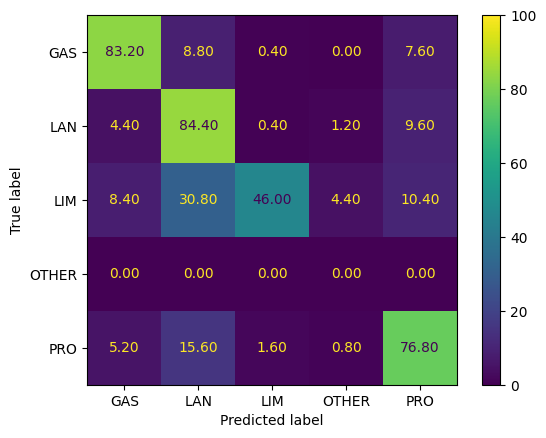

Predict and evaluate with model forum-train
Computed all predictions in 0:00:04.573672


Classification report:
              precision    recall  f1-score   support

         gas     0.9000    0.9000    0.9000       250
         lan     0.8473    0.8880    0.8672       250
         lim     0.7993    0.9240    0.8571       250
         pro     0.9799    0.7800    0.8686       250

    accuracy                         0.8730      1000
   macro avg     0.8816    0.8730    0.8732      1000
weighted avg     0.8816    0.8730    0.8732      1000





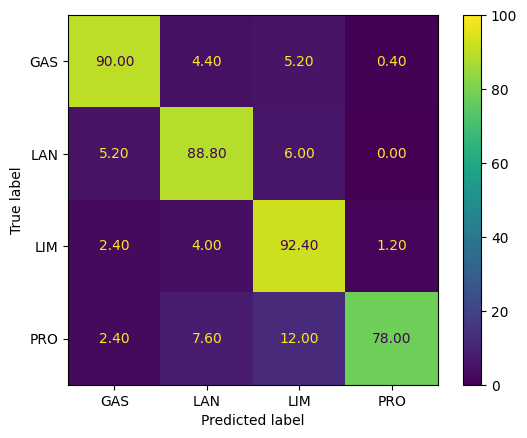

,f1_macro,accuracy,precision_macro,recall_macro,f1_gas,f1_lan,f1_lim,f1_pro,precision_gas,precision_lan,precision_lim,precision_pro,recall_gas,recall_lan,recall_lim,recall_pro,f1_other,precision_other,recall_other,speed_avg
forum-train,0.873232,0.873,0.881634,0.873,0.900000,0.867188,0.857143,0.868597,0.900000,0.847328,0.799308,0.979899,0.900,0.888,0.924,0.780,NaN,NaN,NaN,4.573672
concat-train,0.691296,0.863,0.699673,0.863,0.899384,0.828729,0.884615,0.843750,0.924051,0.767918,0.851852,0.954545,0.876,0.900,0.920,0.756,0.0,0.0,NaN,4.516429
wiki-train,0.580592,0.726,0.622553,0.726,0.827038,0.704508,0.619946,0.751468,0.822134,0.604585,0.950413,0.735632,0.832,0.844,0.460,0.768,0.0,0.0,NaN,4.605122
ttb-train,0.525480,0.542,0.762778,0.542,0.761905,0.533333,0.428135,0.378549,0.879581,0.366917,0.909091,0.895522,0.672,0.976,0.280,0.240,NaN,NaN,NaN,4.524999
congres-train,0.356309,0.454,0.741405,0.454,0.763006,0.486938,0.106061,0.069231,0.736059,0.329562,1.000000,0.900000,0.792,0.932,0.056,0.036,NaN,NaN,NaN,4.521953
baseline_random,0.250000,0.250,0.250000,0.250,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250,0.250,0.250,0.250,NaN,NaN,NaN,NaN
soft-train,0.215310,0.340,0.546207,0.340,0.343234,0.439462,0.113208,0.180645,0.981132,0.283237,1.000000,0.466667,0.208,0.980,0.060,0.112,0.0,0.0,NaN,4.550028


In [29]:
test_name = "forum"
all_results_alltestsets[test_name] = evaluate_all_models_on_testset(test_name, train_clfs)
show_results_table(all_results_alltestsets[test_name])

# Aggregate scores

In [30]:
# Reorder results dict
datasets_order = ["concat", "wiki", "ttb", "congres", "soft", "forum"]
all_results_alltestsets = {ds_name: all_results_alltestsets[ds_name] for ds_name in datasets_order}

In [31]:
def aggregate_mean_std(name_patterns, 
                       all_results_alltestsets, 
                       best_metric="f1_macro", 
                       result_index_name="Training dataset"):
    results_avg_patterns = {}
    for pattern_name in name_patterns:
        # Get best scores for each testset
        results_rows = {}   
        for test_name, res_dict in all_results_alltestsets.items():
            best_scores = None
            for model_name, scores in res_dict.items():
                if pattern_name not in model_name:
                    continue
                if not best_scores or scores[best_metric] > best_scores[best_metric]:
                    best_scores = scores
            results_rows[test_name] = best_scores
        # Concatenate results
        df_pattern = pd.DataFrame.from_dict(
            results_rows, orient="index"
        )
        # Compute average and std
        scores_avg = df_pattern.mean(axis=0, skipna=True)
        scores_std = df_pattern.std(axis=0, skipna=True)
    
        # Merge into a DataFrame with 1 row and all columns (add suffix _avg or _std)
        scores_avg = pd.DataFrame([scores_avg]).add_suffix('_avg')
        scores_std = pd.DataFrame([scores_std]).add_suffix('_std')
        scores_avg = pd.concat([scores_avg, scores_std], axis=1)
        scores_avg.index = [pattern_name]
        
        # Store results
        results_avg_patterns[pattern_name] = scores_avg
    
    df_results_avg_patterns = pd.concat(results_avg_patterns.values()).sort_values(best_metric+"_avg", ascending=False)
    df_results_avg_patterns.index.name = result_index_name
    return df_results_avg_patterns

In [32]:
# Per training dataset
# Average over best per testset + std
df_results_avg_train = aggregate_mean_std(
    train_datasets, 
    all_results_alltestsets,
    result_index_name="Training dataset")
df_results_avg_train

,f1_macro_avg,accuracy_avg,precision_macro_avg,recall_macro_avg,f1_ara_avg,f1_auv_avg,f1_gas_avg,f1_lan_avg,f1_lim_avg,f1_nic_avg,...,recall_gas_std,recall_lan_std,recall_lim_std,recall_nic_std,recall_pro_std,recall_viv_std,speed_avg_std,f1_other_std,precision_other_std,recall_other_std
Training dataset,,,,,,,,,,,,,,,,,,,,,
concat,0.540768,0.704266,0.654695,0.593977,0.319106,0.403942,0.791013,0.735828,0.695986,0.418158,...,0.047520,0.037720,0.162143,0.083468,0.212613,0.103574,2.226045,0.0,0.0,NaN
wiki,0.494428,0.625538,0.655936,0.546902,0.506173,0.426794,0.722607,0.667361,0.585490,0.430409,...,0.057994,0.097860,0.146706,0.219299,0.096577,0.101366,2.253559,0.0,0.0,NaN
forum,0.417675,0.564210,0.542870,0.489629,0.000000,0.000000,0.681109,0.629455,0.473703,0.000000,...,0.059875,0.132720,0.128306,0.000000,0.213919,0.000000,2.240636,NaN,NaN,NaN
ttb,0.344746,0.522178,0.602597,0.362508,0.000000,0.000000,0.645442,0.574958,0.287054,0.000000,...,0.117458,0.023201,0.122287,0.000000,0.149073,0.000000,2.226444,NaN,NaN,NaN
congres,0.257534,0.471804,0.542209,0.323221,0.240770,0.001816,0.642945,0.544537,0.116652,0.000000,...,0.080504,0.078761,0.038870,0.000000,0.076191,0.000000,2.231139,NaN,NaN,NaN
soft,0.220465,0.426092,0.510756,0.270513,0.000000,0.066472,0.381216,0.524159,0.123775,0.187368,...,0.131478,0.042665,0.136932,0.096873,0.068728,0.098452,2.226175,0.0,0.0,NaN


In [33]:
def get_metric_matrix(train_datasets, 
                      all_results_alltestsets, 
                      metric="f1_macro"):
    scores_matrix = {}
    # Get scores for each model (training dataset)
    for train_data in train_datasets:
        # Get scores for each testset
        train_scores = []

        for test_name, test_scores in all_results_alltestsets.items():
            model_name = f"{train_data}-train"
            if model_name in test_scores:
                test_score = test_scores[model_name][metric]
            else:
                test_score = None
            train_scores.append(test_score)
        scores_matrix[train_data] = train_scores
    # Put in a DataFrame
    df_matrix = pd.DataFrame.from_dict(scores_matrix, orient="index", columns=list(all_results_alltestsets))
    df_matrix *= 100
    
    return df_matrix

df_metric_matrix = get_metric_matrix(train_datasets, all_results_alltestsets)
df_metric_matrix

,concat,wiki,ttb,congres,soft,forum
concat,53.473367,53.921718,57.354201,46.179696,44.402487,69.129573
wiki,53.426740,59.544844,44.091389,49.386029,32.148823,58.059182
congres,19.784850,15.661957,31.627764,36.543455,15.271389,35.630888
soft,19.858226,11.950279,27.901477,14.386449,36.651887,21.530978
ttb,23.020898,20.355410,64.165773,28.784441,17.973303,52.548039
forum,28.290544,26.251439,53.494029,34.466292,20.779631,87.323181


In [34]:
def get_metric_baseline(all_results_alltestsets, metric="f1_macro", baseline_name="baseline_random"):
    scores = {}

    # Get baseline score for each test set
    for test_name, test_scores in all_results_alltestsets.items():
        baseline_score = test_scores[baseline_name][metric]
        scores[test_name] = baseline_score
    # Put in a DataFrame
    df_baseline = pd.DataFrame(scores, index=[baseline_name])
    df_baseline *= 100
    return df_baseline

df_baseline = get_metric_baseline(all_results_alltestsets)
df_baseline

,concat,wiki,ttb,congres,soft,forum
baseline_random,11.321189,12.06621,19.07654,10.589316,12.519257,25.0


In [35]:
# F1-macro + P&R per dialect, on concat (train+test)
model_results = all_results_alltestsets["concat"]["concat-train"]

# Get F1-macro
dialect_results = {"f1_macro": model_results["f1_macro"]}

# Get precision and recall per dialect
dialects = [metric.replace("f1_", "") for metric in model_results if metric.startswith("f1_") and not metric.endswith("macro")]
for dia in dialects:
    dialect_results[f"precision_{dia}"] = model_results[f"precision_{dia}"]
    dialect_results[f"recall_{dia}"] = model_results[f"recall_{dia}"]

# Get average runtime per sample (in ms/sample)
dialect_results["speed_avg"] = model_results["speed_avg"]

df_per_dialect = pd.DataFrame(dialect_results, index=["svm"])
df_per_dialect.loc[:, df_per_dialect.columns != 'speed_avg'] *= 100
df_per_dialect

,f1_macro,precision_ara,recall_ara,precision_auv,recall_auv,precision_gas,recall_gas,precision_lan,recall_lan,precision_lim,recall_lim,precision_nic,recall_nic,precision_pro,recall_pro,precision_viv,recall_viv,speed_avg
svm,53.473367,86.206897,16.233766,58.11138,39.800995,75.691583,82.594733,58.49228,88.299817,79.389313,69.267364,83.196721,26.22739,62.001352,65.081618,54.938272,17.45098,3.577016


In [36]:
# F1-macro + P&R per dialect, for the random baseline evaluated on concat-test
# baseline_random
model_results = all_results_alltestsets["concat"]["baseline_random"]
dialects = [metric.replace("f1_", "") for metric in model_results if metric.startswith("f1_") and not metric.endswith("macro")]
dialect_results = {"f1_macro": model_results["f1_macro"]}
for dia in dialects:
    dialect_results[f"precision_{dia}"] = model_results[f"precision_{dia}"]
    dialect_results[f"recall_{dia}"] = model_results[f"recall_{dia}"]

df_per_dialect = pd.DataFrame(dialect_results, index=["baseline_random"])
df_per_dialect.loc[:, df_per_dialect.columns != 'speed_avg'] *= 100
display(df_per_dialect)
print(df_per_dialect.to_latex(float_format="%.2f"))

,f1_macro,precision_ara,recall_ara,precision_auv,recall_auv,precision_gas,recall_gas,precision_lan,recall_lan,precision_lim,recall_lim,precision_nic,recall_nic,precision_pro,recall_pro,precision_viv,recall_viv
baseline_random,11.321189,1.867572,12.5,7.312636,12.5,18.881882,12.5,26.534077,12.5,12.745574,12.5,9.386369,12.5,17.087073,12.5,6.184817,12.5


\begin{tabular}{lrrrrrrrrrrrrrrrrr}
\toprule
 & f1_macro & precision_ara & recall_ara & precision_auv & recall_auv & precision_gas & recall_gas & precision_lan & recall_lan & precision_lim & recall_lim & precision_nic & recall_nic & precision_pro & recall_pro & precision_viv & recall_viv \\
\midrule
baseline_random & 11.32 & 1.87 & 12.50 & 7.31 & 12.50 & 18.88 & 12.50 & 26.53 & 12.50 & 12.75 & 12.50 & 9.39 & 12.50 & 17.09 & 12.50 & 6.18 & 12.50 \\
\bottomrule
\end{tabular}



In [37]:
# Export all scores to JSON
with open(scores_path, "w") as f:
    json.dump(all_results_alltestsets, f)